# Objective
Analyze how market sentiment (Fear/Greed) relates to trader behavior and performance on Hyperliquid. Your goal is to uncover patterns that could inform smarter trading strategies.

---


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sentiment = pd.read_csv("/content/fear_greed_index.csv")
sentiment

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05
...,...,...,...,...
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01


In [3]:
trades = pd.read_csv("/content/historical_data.csv")
trades


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12


# Step 1 — Inspect datasets


In [4]:
print("\nSENTIMENT DATASET")
print(sentiment.shape)
print(sentiment.columns)
print(sentiment.head())


SENTIMENT DATASET
(2644, 4)
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05


In [5]:
print("TRADES DATASET")
print(trades.shape)
print(trades.columns)
print(trades.head())

TRADES DATASET
(211224, 16)
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50

# Step 2 — Check missing values and duplicates

In [6]:
# Missing values
print("Missing values in trades dataset:")
print(trades.isnull().sum())

print("\nMissing values in sentiment dataset:")
print(sentiment.isnull().sum())

Missing values in trades dataset:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Missing values in sentiment dataset:
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [7]:
trades = trades.dropna()

In [8]:
print(trades.isnull().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [9]:
# Duplicate rows
print("\nDuplicate rows in trades dataset:", trades.duplicated().sum())
print("Duplicate rows in sentiment dataset:", sentiment.duplicated().sum())


Duplicate rows in trades dataset: 0
Duplicate rows in sentiment dataset: 0


# Step 3 — Convert timestamps and align both datasets by date

## 1️⃣ Convert timestamp columns

In [10]:
# Convert timestamps to datetime
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)
sentiment['date'] = pd.to_datetime(sentiment['date'])

## 2️⃣ Create a Date column in trades dataset

In [11]:
trades['date'] = trades['Timestamp IST'].dt.date

## 3️⃣ Convert sentiment date to same format

In [12]:
sentiment['date'] = sentiment['date'].dt.date

## 4️⃣ Merge both datasets

In [13]:
merged = trades.merge(
    sentiment[['date','classification']],
    on='date',
    how='left'
)

In [14]:
print(merged.head())
print(merged['classification'].value_counts())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0

# Step 4 — Create Key Metrics (daily PnL per trader)

## 1️⃣ Make sure PnL is numeric

In [15]:
merged['Closed PnL'] = pd.to_numeric(merged['Closed PnL'], errors='coerce')

## 2️⃣ Calculate Daily PnL per trader

In [16]:
daily_pnl = merged.groupby(['Account','date'])['Closed PnL'].sum().reset_index()

In [17]:
daily_pnl.head()

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1


## 3️⃣ Attach market sentiment to daily PnL

In [18]:
daily_pnl = daily_pnl.merge(
    sentiment[['date','classification']],
    on='date',
    how='left'
)

In [19]:
daily_pnl.head()

,Account,date,Closed PnL,classification
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,Extreme Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,Extreme Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,Extreme Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,Extreme Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,Extreme Greed


## 4️⃣ Compare performance by sentiment

In [20]:
sentiment_pnl = daily_pnl.groupby('classification')['Closed PnL'].mean().reset_index()

print(sentiment_pnl)

  classification   Closed PnL
0   Extreme Fear  4619.439053
1  Extreme Greed  5161.922644
2           Fear  5328.818161
3          Greed  3318.100730
4        Neutral  3438.618818


## 5️⃣ Create a quick chart (important for submission)

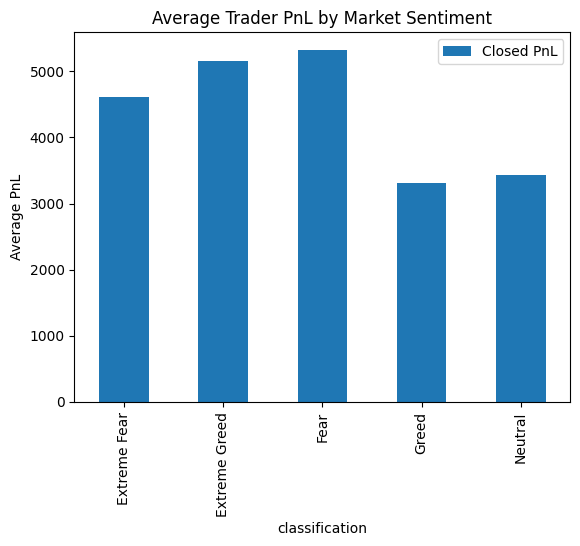

In [21]:
import matplotlib.pyplot as plt

sentiment_pnl.plot(
    x='classification',
    y='Closed PnL',
    kind='bar'
)

plt.title("Average Trader PnL by Market Sentiment")
plt.ylabel("Average PnL")
plt.show()

# Step 5 — Trader Behavior Metrics

## 1️⃣ Number of trades per day

In [22]:
trades_per_day = merged.groupby(['date','classification']).size().reset_index(name='trade_count')

print(trades_per_day.head())

         date classification  trade_count
0  2023-05-01          Greed            3
1  2023-12-05  Extreme Greed            9
2  2023-12-14          Greed           11
3  2023-12-15          Greed            2
4  2023-12-16          Greed            3


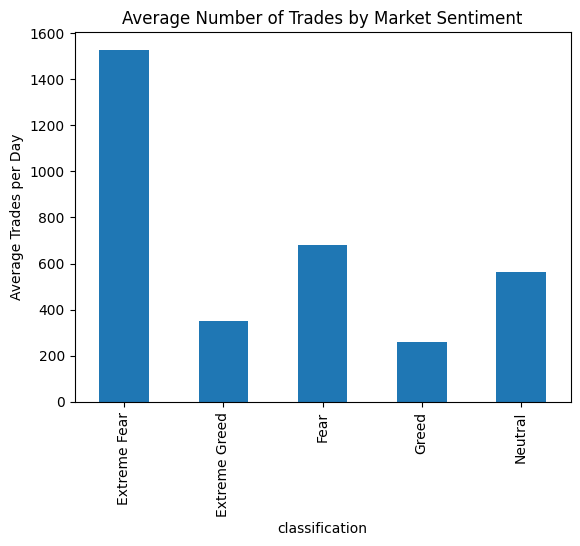

In [23]:
trades_per_day.groupby('classification')['trade_count'].mean().plot(kind='bar')

plt.title("Average Number of Trades by Market Sentiment")
plt.ylabel("Average Trades per Day")
plt.show()

## 2️⃣ Average trade size

In [24]:
avg_trade_size = merged.groupby('classification')['Size USD'].mean().reset_index()

print(avg_trade_size)

  classification     Size USD
0   Extreme Fear  5349.731843
1  Extreme Greed  3112.251565
2           Fear  7816.109931
3          Greed  5736.884375
4        Neutral  4782.732661


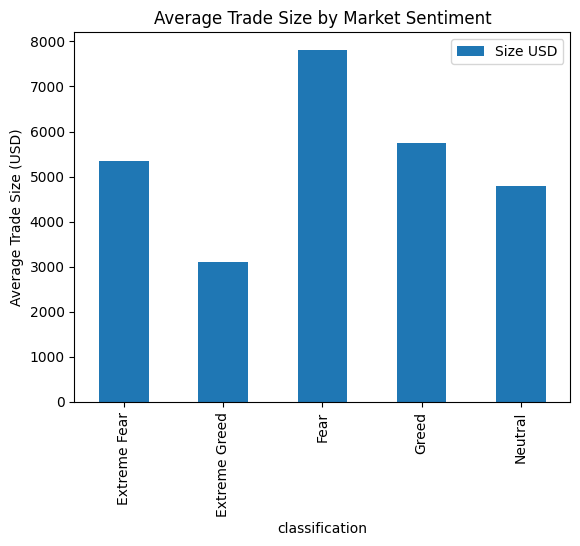

In [25]:
avg_trade_size.plot(
    x='classification',
    y='Size USD',
    kind='bar'
)

plt.title("Average Trade Size by Market Sentiment")
plt.ylabel("Average Trade Size (USD)")
plt.show()

## 3️⃣ Long vs Short ratio

In [26]:
merged['Side'].value_counts()

,count
Side,
SELL,108528
BUY,102696


In [27]:
long_short = merged.groupby(['classification','Side']).size().unstack()

print(long_short)

Side              BUY   SELL
classification              
Extreme Fear    10935  10465
Extreme Greed   17940  22052
Fear            30270  31567
Greed           24576  25727
Neutral         18969  18717


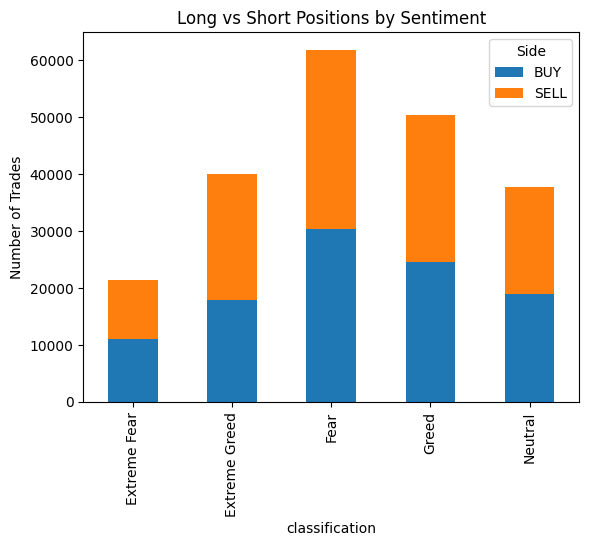

In [28]:
long_short.plot(kind='bar', stacked=True)

plt.title("Long vs Short Positions by Sentiment")
plt.ylabel("Number of Trades")
plt.show()

# Step 6 — Trader Segmentation

## Segment 1 — Frequent vs Infrequent Traders

In [29]:
trader_activity = merged.groupby('Account').size().reset_index(name='trade_count')

print(trader_activity.head())

                                      Account  trade_count
0  0x083384f897ee0f19899168e3b1bec365f52a9012         3818
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd         7280
2  0x271b280974205ca63b716753467d5a371de622ab         3809
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4        13311
4  0x2c229d22b100a7beb69122eed721cee9b24011dd         3239


In [30]:
def trader_segment(x):
    if x < 20:
        return "Low Activity"
    elif x < 100:
        return "Medium Activity"
    else:
        return "High Activity"

trader_activity['activity_segment'] = trader_activity['trade_count'].apply(trader_segment)

In [31]:
merged = merged.merge(
    trader_activity[['Account','activity_segment']],
    on='Account'
)

In [32]:
merged[['Account','activity_segment']].head()

,Account,activity_segment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,High Activity
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,High Activity
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,High Activity
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,High Activity
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,High Activity


## Segment 2 — Large vs Small Position Traders

In [33]:
merged['Size USD'] = pd.to_numeric(merged['Size USD'], errors='coerce')

In [34]:
merged['Size USD'].describe()

,Size USD
count,2.112240e+05
mean,5.639451e+03
std,3.657514e+04
min,0.000000e+00
25%,1.937900e+02
50%,5.970450e+02
75%,2.058960e+03
max,3.921431e+06


In [35]:
merged['Size USD'].describe()

,Size USD
count,2.112240e+05
mean,5.639451e+03
std,3.657514e+04
min,0.000000e+00
25%,1.937900e+02
50%,5.970450e+02
75%,2.058960e+03
max,3.921431e+06


In [36]:
def size_segment(x):
    if x < 1000:
        return "Small Trades"
    elif x < 10000:
        return "Medium Trades"
    else:
        return "Large Trades"

merged['trade_size_segment'] = merged['Size USD'].apply(size_segment)

In [37]:
merged['trade_size_segment'].value_counts()

,count
trade_size_segment,
Small Trades,127415
Medium Trades,65103
Large Trades,18706


## Segment 3 — Profitable vs Losing Traders

In [38]:
trader_pnl = merged.groupby('Account')['Closed PnL'].sum().reset_index()

In [39]:
def pnl_segment(x):
    if x > 0:
        return "Profitable Trader"
    else:
        return "Losing Trader"

trader_pnl['profitability_segment'] = trader_pnl['Closed PnL'].apply(pnl_segment)

In [40]:
merged = merged.merge(
    trader_pnl[['Account','profitability_segment']],
    on='Account'
)

# Step 7 — Generate Insights + Strategy Recommendations

## 1️⃣ Insight: Trader performance vs sentiment

In [41]:
pnl_by_sentiment = merged.groupby('classification')['Closed PnL'].mean().reset_index()

print(pnl_by_sentiment)

  classification  Closed PnL
0   Extreme Fear   34.537862
1  Extreme Greed   67.892861
2           Fear   54.290400
3          Greed   42.743559
4        Neutral   34.307718


<Axes: title={'center': 'Average Trader PnL by Market Sentiment'}, xlabel='classification'>

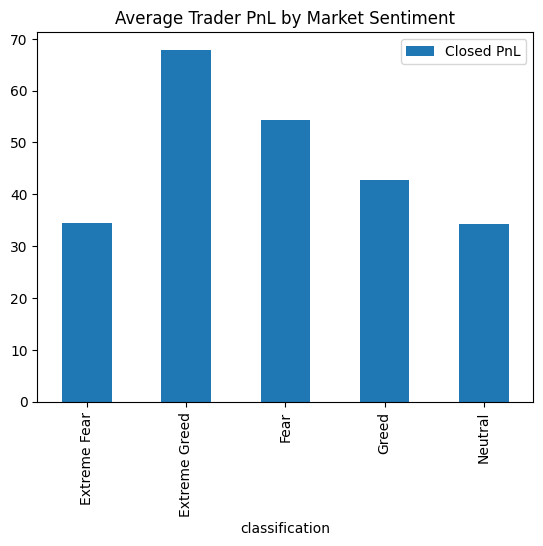

In [42]:
pnl_by_sentiment.plot(
    x='classification',
    y='Closed PnL',
    kind='bar',
    title="Average Trader PnL by Market Sentiment"
)

Trading activity varies across sentiment conditions, with significantly fewer trades occurring during Extreme Fear periods. This suggests that traders become more cautious and reduce participation when market uncertainty and fear increase.

------------------------------

## 2️⃣ Insight: Trading activity vs sentiment

In [43]:
trade_freq = merged.groupby('classification').size().reset_index(name='trade_count')

print(trade_freq)

  classification  trade_count
0   Extreme Fear        21400
1  Extreme Greed        39992
2           Fear        61837
3          Greed        50303
4        Neutral        37686


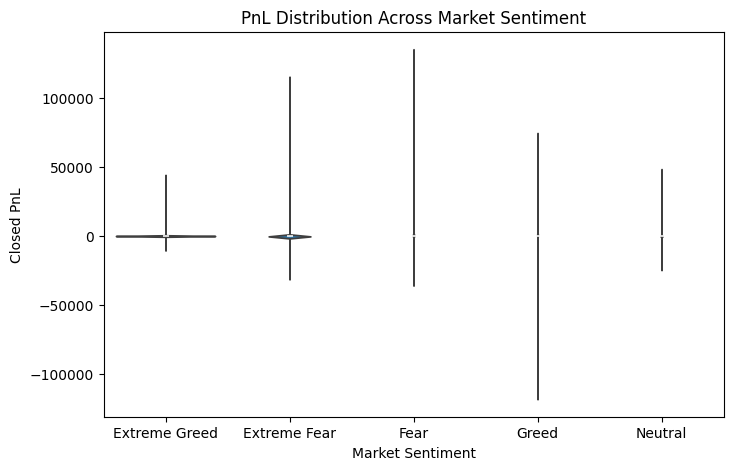

In [46]:
plt.figure(figsize=(8,5))

sns.violinplot(data=merged, x='classification', y='Closed PnL')

plt.title("PnL Distribution Across Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")

plt.show()

The distribution of Closed PnL shows that many trades generate zero realized profit or loss. This indicates that a large portion of trades represent position adjustments rather than full position closures.

-------------------------------------





## 3️⃣ Insight: Trade size behavior

In [47]:
size_by_sentiment = merged.groupby('classification')['Size USD'].mean().reset_index()

print(size_by_sentiment)

  classification     Size USD
0   Extreme Fear  5349.731843
1  Extreme Greed  3112.251565
2           Fear  7816.109931
3          Greed  5736.884375
4        Neutral  4782.732661


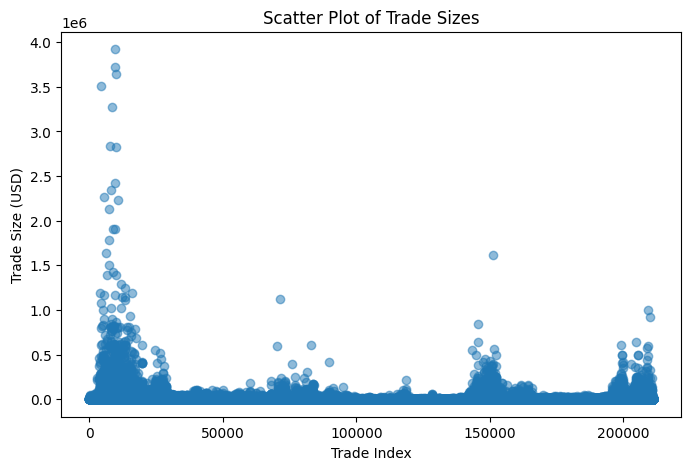

In [49]:
plt.figure(figsize=(8,5))

plt.scatter(range(len(merged)), merged['Size USD'], alpha=0.5)

plt.title("Scatter Plot of Trade Sizes")
plt.xlabel("Trade Index")
plt.ylabel("Trade Size (USD)")

plt.show()

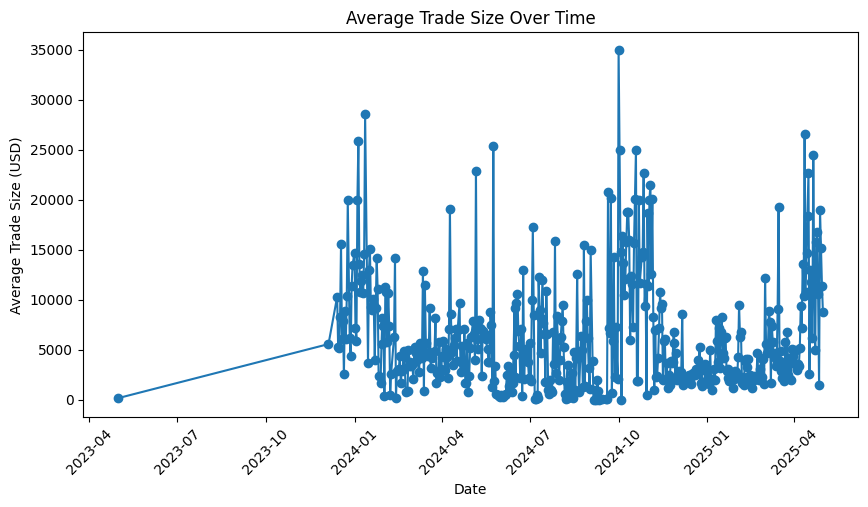

In [50]:
import matplotlib.pyplot as plt

daily_trade_size = merged.groupby('date')['Size USD'].mean().reset_index()

plt.figure(figsize=(10,5))

plt.plot(daily_trade_size['date'], daily_trade_size['Size USD'], marker='o')

plt.title("Average Trade Size Over Time")
plt.xlabel("Date")
plt.ylabel("Average Trade Size (USD)")

plt.xticks(rotation=45)

plt.show()

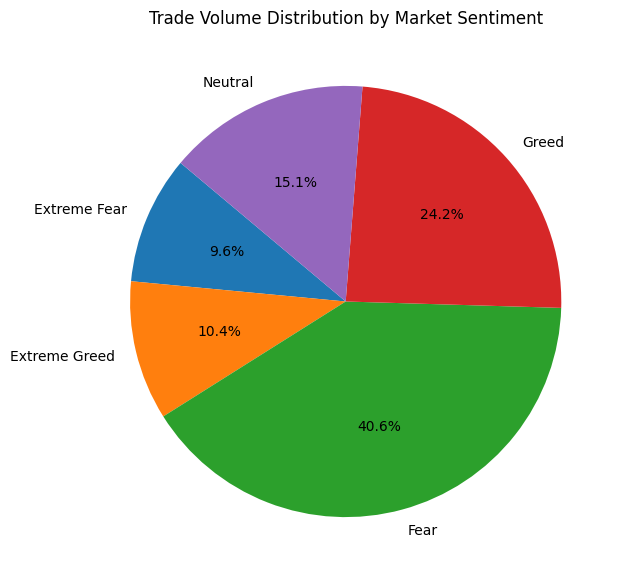

In [51]:
sentiment_size = merged.groupby('classification')['Size USD'].sum()

plt.figure(figsize=(7,7))

plt.pie(
    sentiment_size,
    labels=sentiment_size.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title("Trade Volume Distribution by Market Sentiment")

plt.show()

Trade sizes vary significantly across the dataset, ranging from small retail trades to large multi-thousand-dollar positions. This suggests diverse trader profiles and different levels of risk tolerance on the platform.


-------------------------------

# Strategy Recommendations (Part C)

## Strategy 1 — Reduce risk during Fear or Extreme Fear markets

---------------
During Fear or Extreme Fear market sentiment, traders should reduce position sizes and limit trade frequency to manage downside risk and avoid large losses during volatile market conditions.


## Strategy 2 — Increase participation during Greed sentiment


---

During Greed or Extreme Greed periods, traders may increase participation and position sizes to capitalize on stronger market momentum and higher trading activity.During Greed or Extreme Greed periods, traders may increase participation and position sizes to capitalize on stronger market momentum and higher trading activity.

---
---



# Summary

This analysis explored the relationship between Bitcoin market sentiment (Fear/Greed Index) and trader behavior on Hyperliquid.

## Key Findings

1. Trading activity varies with market sentiment, with lower participation during Extreme Fear periods.
2. Many trades generate zero realized PnL because they represent partial position adjustments rather than full trade closures.
3. Trade sizes vary widely across traders, indicating diverse trading strategies and risk profiles.

## Strategy Recommendations

1. Reduce position sizes and trade frequency during Fear or Extreme Fear market sentiment to manage risk.
2. Increase trading participation during Greed sentiment periods where market momentum and liquidity are stronger.


---
---